<a href="https://colab.research.google.com/github/DanielLucero25/CSC349/blob/main/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve
)

## Task 1: Load the Dataset
Load the Telco Customer Churn dataset into a Pandas DataFrame.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Task 2: Inspect the Dataset
Use head(), info(), and describe() to inspect the structure, data types, numerical features, and categorical features.

In [ ]:
print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nNumerical Summary:")
display(df.describe())

print("\nSelected Features:")
display(
    df[
        [
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "Contract",
            "PaymentMethod"
        ]
    ].head(10)
)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Selected Features:


,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod
0,1,29.85,29.85,Month-to-month,Electronic check
1,34,56.95,1889.5,One year,Mailed check
2,2,53.85,108.15,Month-to-month,Mailed check
3,45,42.30,1840.75,One year,Bank transfer (automatic)
4,2,70.70,151.65,Month-to-month,Electronic check
5,8,99.65,820.5,Month-to-month,Electronic check
6,22,89.10,1949.4,Month-to-month,Credit card (automatic)
7,10,29.75,301.9,Month-to-month,Mailed check
8,28,104.80,3046.05,Month-to-month,Electronic check
9,62,56.15,3487.95,One year,Bank transfer (automatic)


## Task 3: Remove Non-Informative Identifiers
The customerID column uniquely identifies each customer but does not provide useful predictive information, so it will be removed.

In [ ]:
df = df.drop(columns=["customerID"])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Task 4: Identify Missing and Implicit Missing Values
Check for missing values, identify whitespace values in TotalCharges, convert TotalCharges to a numeric feature, and prepare an imputation strategy using SimpleImputer.

In [ ]:
print("Normal missing values:")
print(df.isnull().sum())

Normal missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
blank_total_charges = (df["TotalCharges"].str.strip() == "").sum()

print("Blank TotalCharges values:", blank_total_charges)

Blank TotalCharges values: 11


In [ ]:
df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
print(df["TotalCharges"].dtype)

print("\nMissing values after conversion:")
print(df.isnull().sum())

float64

Missing values after conversion:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
X = df.drop(columns=["Churn"])

y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(X.shape)
print(y.value_counts())

(7043, 19)
Churn
0    5174
1    1869
Name: count, dtype: int64


## Task 5: Create Numerical and Categorical Preprocessing Pipelines
Separate numerical and categorical features. Numerical features will be imputed and scaled, while categorical features will be imputed and converted using OneHotEncoder. ColumnTransformer will combine these preprocessing steps.

In [ ]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
numerical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

In [ ]:
preprocessor = ColumnTransformer([
    (
        "num",
        numerical_pipeline,
        numerical_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## Task 6: Add Logistic Regression with SGDClassifier
Create a complete Scikit-Learn Pipeline using SGDClassifier with loss='log_loss' so the model performs logistic regression and supports probability predictions.

In [ ]:
model = SGDClassifier(
    loss="log_loss",
    max_iter=2000,
    tol=1e-3,
    random_state=42
)

complete_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        model
    )
])

complete_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 SGDClassifier(loss='log_loss', max_iter=2000,
                               random_state=42))])

## Task 7: Evaluate Three Train/Test Split Ratios
Train and evaluate the complete pipeline using 80/20, 70/30, and 60/40 train/test splits. Compare confusion matrices, classification reports, ROC curves, and ROC-AUC scores.

In [ ]:
split_ratios = {
    "80/20": 0.20,
    "70/30": 0.30,
    "60/40": 0.40
}

results = {}
trained_models = {}

Split: 80/20

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1035
           1       0.64      0.44      0.52       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



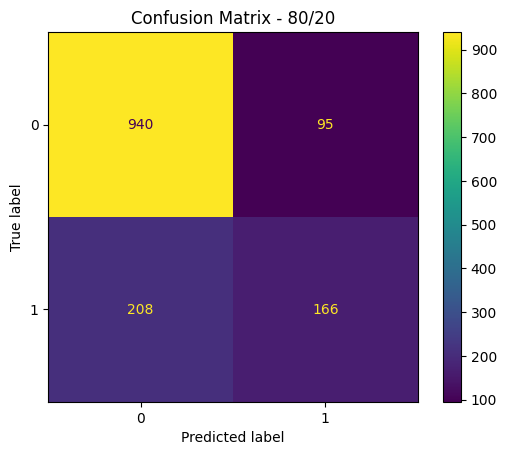

Split: 70/30

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.65      0.54      0.59       561

    accuracy                           0.80      2113
   macro avg       0.75      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



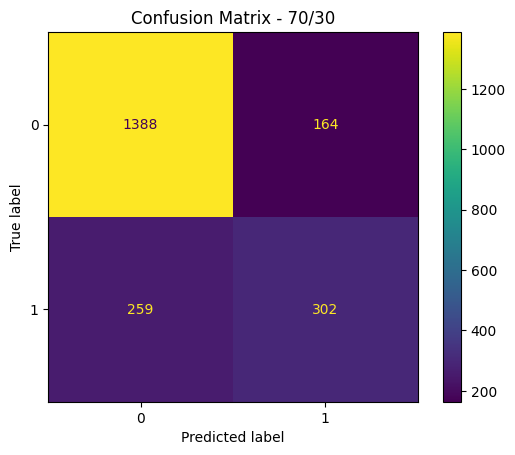

Split: 60/40

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      2070
           1       0.60      0.61      0.60       748

    accuracy                           0.79      2818
   macro avg       0.73      0.73      0.73      2818
weighted avg       0.79      0.79      0.79      2818



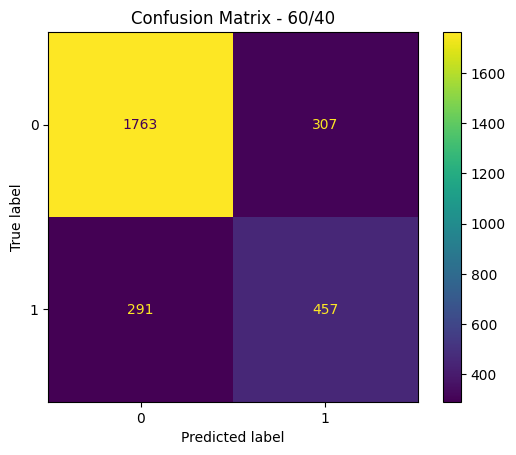

In [ ]:
for name, test_size in split_ratios.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    complete_pipeline.fit(
        X_train,
        y_train
    )

    y_pred = complete_pipeline.predict(X_test)

    y_prob = complete_pipeline.predict_proba(X_test)[:, 1]

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    results[name] = {
        "ROC-AUC": auc_score,
        "Training Size": len(X_train),
        "Test Size": len(X_test)
    }

    trained_models[name] = complete_pipeline

    print("=" * 50)
    print("Split:", name)
    print("=" * 50)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.show()

## Additional Experiment: StandardScaler vs MinMaxScaler
Compare StandardScaler and MinMaxScaler to determine whether scaling strategy affects SGDClassifier performance.

In [ ]:
results_df = pd.DataFrame(results).T

results_df

,ROC-AUC,Training Size,Test Size
80/20,0.829642,5634.0,1409.0
70/30,0.842057,4930.0,2113.0
60/40,0.834722,4225.0,2818.0


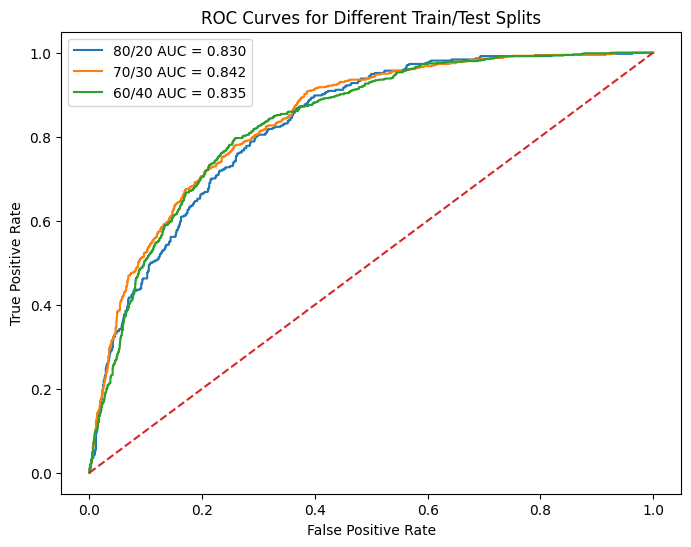

In [ ]:
plt.figure(figsize=(8, 6))

for name, test_size in split_ratios.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            SGDClassifier(
                loss="log_loss",
                max_iter=2000,
                tol=1e-3,
                random_state=42
            )
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC = {auc_score:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Train/Test Splits")
plt.legend()

plt.show()

The three train/test configurations produced similar overall results. The 80/20 split provided the model with the largest training set, while the 60/40 configuration used fewer observations for training but provided a larger test sample. The ROC-AUC scores remained relatively similar across the splits, suggesting that the model's performance was reasonably stable. Small differences in precision, recall, and ROC-AUC can occur because the amount of training data changes between configurations.

## Additional Experiment: StandardScaler vs MinMaxScaler
Compare StandardScaler and MinMaxScaler to determine whether scaling strategy affects SGDClassifier performance.

In [ ]:
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

scaler_results = {}

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

for scaler_name, scaler in scalers.items():

    numerical_pipeline_test = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            scaler
        )
    ])

    preprocessor_test = ColumnTransformer([
        (
            "num",
            numerical_pipeline_test,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ])

    pipeline_test = Pipeline([
        (
            "preprocessor",
            preprocessor_test
        ),
        (
            "classifier",
            SGDClassifier(
                loss="log_loss",
                max_iter=2000,
                tol=1e-3,
                random_state=42
            )
        )
    ])

    pipeline_test.fit(
        X_train,
        y_train
    )

    y_pred = pipeline_test.predict(X_test)

    y_prob = pipeline_test.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    scaler_results[scaler_name] = auc

scaler_results

{'StandardScaler': np.float64(0.829641685396161),
 'MinMaxScaler': np.float64(0.8308636234467436)}

In [ ]:
pd.DataFrame(
    scaler_results.items(),
    columns=["Scaler", "ROC-AUC"]
)

,Scaler,ROC-AUC
0,StandardScaler,0.829642
1,MinMaxScaler,0.830864


## Task 8: Interpret Model Coefficients
Inspect the logistic regression coefficients produced by SGDClassifier to determine which transformed features have the strongest relationship with customer churn.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

final_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        SGDClassifier(
            loss="log_loss",
            max_iter=2000,
            tol=1e-3,
            random_state=42
        )
    )
])

final_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 SGDClassifier(loss='log_loss', max_iter=2000,
                               random_state=42))])

In [ ]:
feature_names = (
    final_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    final_pipeline
    .named_steps["classifier"]
    .coef_[0]
)

In [ ]:
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [ ]:
coefficient_df.sort_values(
    "Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
16,cat__InternetService_Fiber optic,1.393056
36,cat__Contract_Month-to-month,1.105818
40,cat__PaperlessBilling_Yes,0.896744
32,cat__StreamingTV_Yes,0.882095
35,cat__StreamingMovies_Yes,0.858323
27,cat__TechSupport_No,0.669562
7,cat__Partner_Yes,0.632036
11,cat__PhoneService_Yes,0.609266
14,cat__MultipleLines_Yes,0.601330
21,cat__OnlineBackup_No,0.594517


In [ ]:
coefficient_df.sort_values(
    "Coefficient"
).head(10)

,Feature,Coefficient
1,num__tenure,-1.218899
2,num__MonthlyCharges,-1.171496
15,cat__InternetService_DSL,-0.497426
38,cat__Contract_Two year,-0.458215
42,cat__PaymentMethod_Credit card (automatic),-0.036214
12,cat__MultipleLines_No,0.007936
30,cat__StreamingTV_No,0.013535
33,cat__StreamingMovies_No,0.037307
39,cat__PaperlessBilling_No,0.061706
25,cat__DeviceProtection_No internet service,0.062820


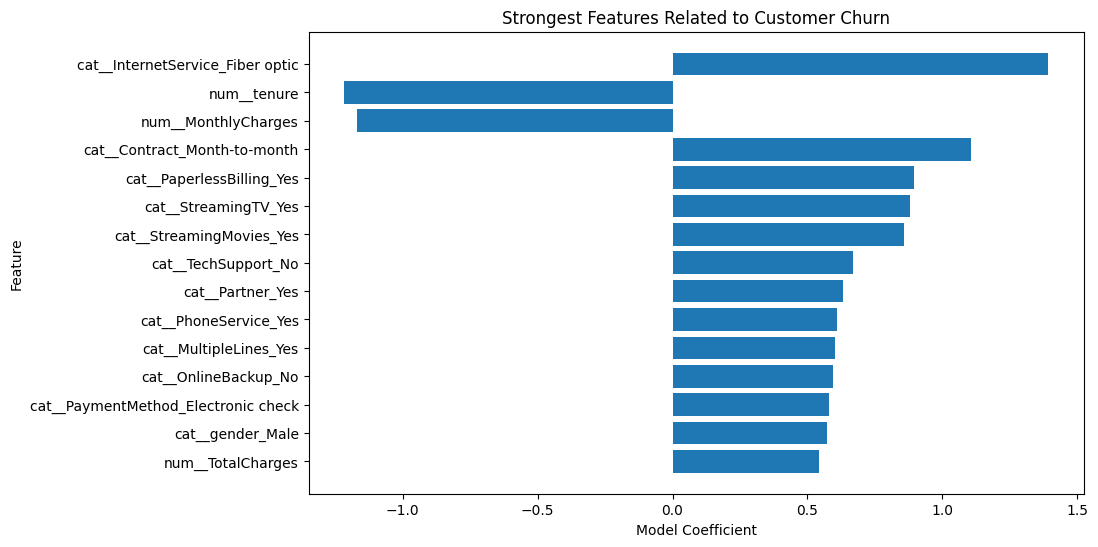

In [ ]:
important_features = (
    coefficient_df
    .assign(
        AbsoluteCoefficient=lambda x:
        x["Coefficient"].abs()
    )
    .sort_values(
        "AbsoluteCoefficient",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10, 6))

plt.barh(
    important_features["Feature"],
    important_features["Coefficient"]
)

plt.xlabel("Model Coefficient")
plt.ylabel("Feature")
plt.title("Strongest Features Related to Customer Churn")

plt.gca().invert_yaxis()

plt.show()